# Notebook 2 | Interactive Hazard Plotter
## GeoINquire Workshop · Messina, April 2026

**Purpose:** Query the EFEHR/SHARE API and produce two types of seismic hazard results:

| Plot type | What it shows | When to use it |
|-----------|--------------|----------------|
| **Hazard Curve** | Annual probability of exceeding a ground-motion level vs. ground-motion level | Comparing models or uncertainty at a single IMT |
| **Uniform Hazard Spectrum (UHS)** | Spectral acceleration vs. structural period at a fixed return period | Engineering design input; comparing response across periods |

### Workflow
```
Notebook 1        →  hazard_config.yaml  →  Notebook 2
(discovery)           (available options)    (plotting)
```

**Prerequisite:** Run Notebook 1 first to generate `hazard_config.yaml` for your target site.

### Key concepts: reading a hazard curve

A hazard curve is essentially the *risk thermometer* of a site. On the x-axis sits the ground motion intensity (e.g., PGA in units of g); on the y-axis sits the annual probability that ground motion will exceed that level. The curve slopes downward — larger ground motions are rarer.

A useful analogy: think of the hazard curve as a **return-period vs. flood-stage curve** in hydrology, but for shaking instead of water. The point on the curve where annual probability = 1/475 ≈ 0.0021 defines the Eurocode seismic design ground motion.

## 1. Install dependencies

In [1]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
                       'pyyaml', 'requests', 'matplotlib', 'numpy', 'ipywidgets'])
print('Dependencies OK.')

Dependencies OK.


## 2. Imports and API helpers

In [2]:
import requests
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import io, yaml, sys
import ipywidgets as widgets
from IPython.display import display, clear_output

BASE_URL    = 'http://appsrvr.share-eu.org:8080/share'
CONFIG_FILE = 'hazard_config.yaml'

def get_xml_root(url, debug=False):
    """Fetch URL, parse XML, strip namespace prefixes."""
    try:
        if debug:
            print(f'  GET {url}')
        r = requests.get(url, timeout=30)
        r.raise_for_status()
        it = ET.iterparse(io.StringIO(r.text))
        for _, el in it:
            _, _, el.tag = el.tag.rpartition('}')
        return it.root
    except Exception as e:
        print(f'  ✗ Error fetching {url}: {e}')
        return None

def load_config():
    """Load hazard_config.yaml generated by Notebook 1."""
    try:
        with open(CONFIG_FILE, 'r') as f:
            cfg = yaml.safe_load(f)
        print(f'Config loaded for site: {cfg["location"]["latitude"]}°N, '
              f'{cfg["location"]["longitude"]}°E')
        return cfg
    except FileNotFoundError:
        print('ERROR: hazard_config.yaml not found. Run Notebook 1 first.')
        return None

print('Helpers loaded.')

Helpers loaded.


## 3. Data fetching functions

In [3]:
def fetch_hazard_curve(lat, lon, model_id, imt, soil, agg_type, agg_level, debug=False):
    """
    Fetch a hazard curve: returns (IML list, PoE list).
    IML = Intensity Measure Level (ground motion values, units of g for PGA/SA)
    PoE = Annual probability of exceedance at each IML
    """
    url = (f'{BASE_URL}/curve?id={model_id}&lon={lon}&lat={lat}'
           f'&imt={imt}&soiltype={soil}'
           f'&aggregationtype={agg_type}&aggregationlevel={agg_level}')
    root = get_xml_root(url, debug=debug)
    if root is None:
        return None, None

    imls, poes = [], []
    for elem in root.iter():
        tag = elem.tag.lower()
        if 'iml' in tag and elem.text:
            try:
                imls = [float(x) for x in elem.text.split()]
            except ValueError:
                pass
        if tag in ('poe', 'ep', 'poes') and elem.text:
            try:
                poes = [float(x) for x in elem.text.split()]
            except ValueError:
                pass

    if not imls or not poes:
        if debug:
            print('  ⚠ Could not parse IML/PoE from response.')
    return imls, poes


def fetch_uhs(lat, lon, model_id, soil, agg_type, agg_level, poe_prob, poe_years, debug=False):
    """
    Fetch a Uniform Hazard Spectrum: returns (periods list, SA values list).
    Uses three progressive parsing strategies to handle API format differences
    between ESHM13, ESHM20, and national models.
    """
    url = (f'{BASE_URL}/spectra?id={model_id}&lon={lon}&lat={lat}&imt=SA'
           f'&poe={poe_prob}&timespanpoe={poe_years}'
           f'&soiltype={soil}&aggregationtype={agg_type}&aggregationlevel={agg_level}')
    root = get_xml_root(url, debug=debug)
    if root is None:
        return None, None

    # Strategy 1: NRML format used by ESHM20
    nrml_periods, nrml_values = None, None
    for elem in root.iter():
        if 'SpectraPeriodList' in elem.tag and elem.text:
            nrml_periods = elem.text
        if 'IML' in elem.tag and elem.text:
            nrml_values = elem.text
    if nrml_periods and nrml_values:
        try:
            periods = [float(x) for x in nrml_periods.split()]
            values  = [float(x) for x in nrml_values.split()]
            pairs = sorted(zip(periods, values))
            return [p for p, v in pairs], [v for p, v in pairs]
        except ValueError:
            pass

    # Strategy 2: Legacy ESHM13 format — look for period and value text nodes
    period_text, value_text = None, None
    for elem in root.iter():
        tag = elem.tag.lower()
        if 'period' in tag and 'list' not in tag and elem.text:
            period_text = elem.text
        if ('value' in tag or 'ordinate' in tag or 'sa' in tag) and elem.text:
            value_text = elem.text
    if period_text and value_text:
        try:
            periods = [float(x) for x in period_text.split()]
            values  = [float(x) for x in value_text.split()]
            if len(periods) == len(values) and len(periods) > 1:
                pairs = sorted(zip(periods, values))
                return [p for p, v in pairs], [v for p, v in pairs]
        except ValueError:
            pass

    # Strategy 3: Point-based format — look for <point x=... y=...>
    x_vals, y_vals = [], []
    for pt in root.iter():
        if 'point' in pt.tag.lower():
            p = pt.get('x') or pt.get('period') or pt.get('T')
            v = pt.get('y') or pt.get('value') or pt.get('sa')
            if p and v:
                x_vals.append(float(p))
                y_vals.append(float(v))
    if x_vals:
        pairs = sorted(zip(x_vals, y_vals))
        return [p for p, v in pairs], [v for p, v in pairs]

    # Debug: print raw XML so the user can inspect
    if debug:
        print('  ⚠ Could not parse UHS response. Raw XML (first 500 chars):')
        try:
            r2 = requests.get(url, timeout=30)
            print(r2.text[:500])
        except Exception:
            pass

    return None, None

print('Fetching functions loaded.')

Fetching functions loaded.


## 4. Plotting function

In [4]:
def plot_scenarios(scenarios, plot_type, title_suffix=''):
    """
    Plot one or more hazard curves or UHS on the same axes.
    
    scenarios: list of dicts with keys 'label', 'x', 'y'
    plot_type: 'curve' or 'uhs'
    """
    valid = [s for s in scenarios if s.get('x') and s.get('y')]
    if not valid:
        print('\n⚠ No data to plot. Possible reasons:')
        print('  • The model does not cover this location')
        print('  • The PoE / soil type combination is not available')
        print('  • Network error — try re-running with debug=True in the fetch calls')
        return

    fig, ax = plt.subplots(figsize=(11, 6))
    colors = cm.tab10(np.linspace(0, 0.9, max(len(valid), 1)))

    for idx, data in enumerate(valid):
        lbl = data['label']
        # Style by aggregation level
        ls, lw, alpha = '-', 2.2, 1.0
        lbl_lower = lbl.lower()
        if any(x in lbl_lower for x in ['0.05', '0.95', 'low', 'high']):
            ls, lw, alpha = ':', 1.4, 0.65
        elif any(x in lbl_lower for x in ['0.16', '0.84']):
            ls, lw, alpha = '--', 1.6, 0.78

        ax.plot(data['x'], data['y'], label=lbl,
                color=colors[idx], linestyle=ls, linewidth=lw, alpha=alpha)

    if plot_type == 'curve':
        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.set_xlabel('Intensity Measure Level [g]', fontsize=12)
        ax.set_ylabel('Annual Probability of Exceedance', fontsize=12)
        ax.set_title(f'Seismic Hazard Curve  {title_suffix}', fontsize=13)
        # Reference return period lines
        for rp, label in [(475, '10%/50y\n(475yr)'), (975, '5%/50y\n(975yr)'),
                          (2475, '2%/50y\n(2475yr)')]:
            ax.axhline(y=1/rp, color='grey', linestyle=':', linewidth=0.9, alpha=0.6)
            ax.text(ax.get_xlim()[0] if ax.get_xlim()[0] > 0 else 1e-4,
                    1/rp * 1.05, label, fontsize=7, color='grey', va='bottom')
    else:
        ax.set_xscale('linear')
        ax.set_xlabel('Spectral Period [s]', fontsize=12)
        ax.set_ylabel('Spectral Acceleration [g]', fontsize=12)
        ax.set_title(f'Uniform Hazard Spectrum  {title_suffix}', fontsize=13)

    ax.grid(True, which='both', linestyle='--', alpha=0.35)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
    plt.tight_layout()
    plt.show()

print('Plotting function loaded.')

Plotting function loaded.


## 5. Load configuration

In [5]:
config = load_config()

if config:
    LAT  = config['location']['latitude']
    LON  = config['location']['longitude']
    MODELS = [m for m in config['available_models']
              if m['name'] and m['parameters'].get('imts')]
    print(f'\nUsable models: {[m["name"] for m in MODELS]}')

Config loaded for site: 38.19°N, 15.55°E

Usable models: ['European Seismic Hazard Model 2013 (ESHM13)', 'European Seismic hazard Model 2020 (ESHM20)']


## 6. Exercise A: Single hazard curve

**Task:** Plot a PGA hazard curve for your site using ESHM20, mean aggregation.

Edit the `SETTINGS` dictionary below, then run the cell.

**Learning goal:** Read off the PGA value at the 475-year return period (annual PoE ≈ 0.0021). This is the Eurocode seismic design ground motion for rock at your site.

Fetching hazard curve for 38.19°N, 15.55°E ...


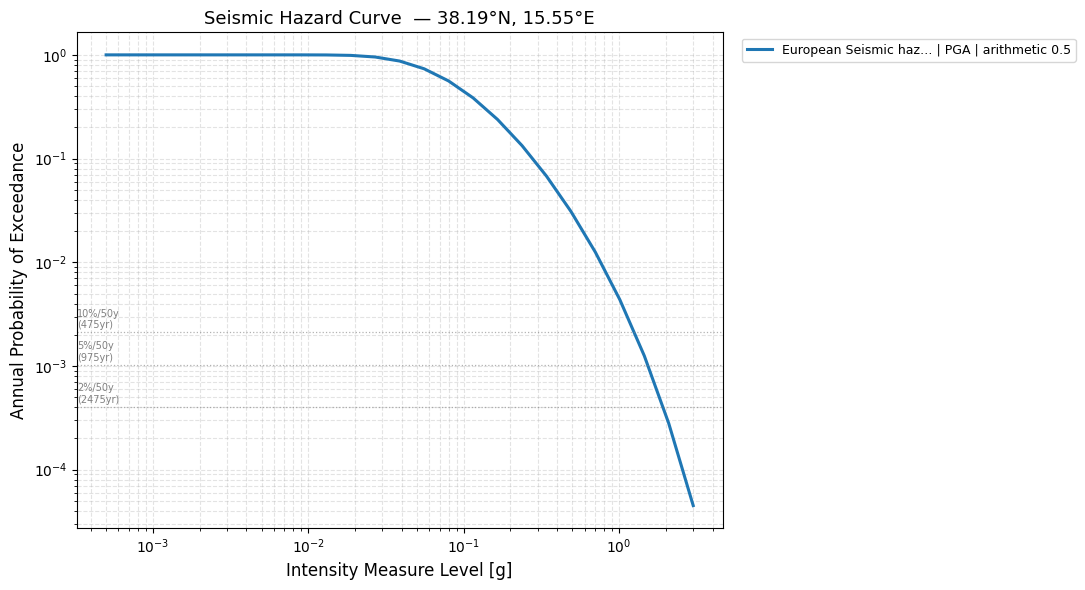

In [6]:
# ============================================================
#  EXERCISE A — edit these settings and run
# ============================================================
SETTINGS = {
    'model_name' : 'European Seismic hazard Model 2020 (ESHM20)',  # from Cell 5 output
    'imt'        : 'PGA',               # e.g. 'PGA', 'SA[0.20s]', 'SA[1.00s]'
    'soil_type'  : 'rock_vs30_800ms-1', # from Cell 5 output
    'agg_type'   : 'arithmetic',        # 'arithmetic' or 'ordinal'
    'agg_level'  : '0.5',               # '0.5' = mean/median; '0.16', '0.84' for bounds
    'debug'      : False,               # set True to print the API URL and raw output
}

# --- Do not edit below this line ---
model = next((m for m in MODELS if m['name'] == SETTINGS['model_name']), None)
if model is None:
    print(f"Model '{SETTINGS['model_name']}' not found. Available: {[m['name'] for m in MODELS]}")
else:
    print(f"Fetching hazard curve for {LAT}°N, {LON}°E ...")
    x, y = fetch_hazard_curve(
        LAT, LON, model['id'],
        SETTINGS['imt'], SETTINGS['soil_type'],
        SETTINGS['agg_type'], SETTINGS['agg_level'],
        debug=SETTINGS['debug']
    )
    label = f"{SETTINGS['model_name'][:20]}… | {SETTINGS['imt']} | {SETTINGS['agg_type']} {SETTINGS['agg_level']}"
    plot_scenarios(
        [{'label': label, 'x': x, 'y': y}],
        plot_type='curve',
        title_suffix=f'— {LAT}°N, {LON}°E'
    )

## 7. Exercise B: Epistemic uncertainty / mean vs. percentiles

**Task:** Plot three hazard curves for the same model and IMT:
- Mean (arithmetic 0.5)
- 16th percentile (lower bound of epistemic uncertainty)
- 84th percentile (upper bound of epistemic uncertainty)

**Learning goal:** The spread between the 16th and 84th percentiles represents *epistemic* uncertainty — our uncertainty in the model itself (source characterisation, GMMs). The wider the band, the less scientific consensus there is about hazard at this site.

  Fetching Mean ...
  Fetching 16th pct. ...
  Fetching 84th pct. ...


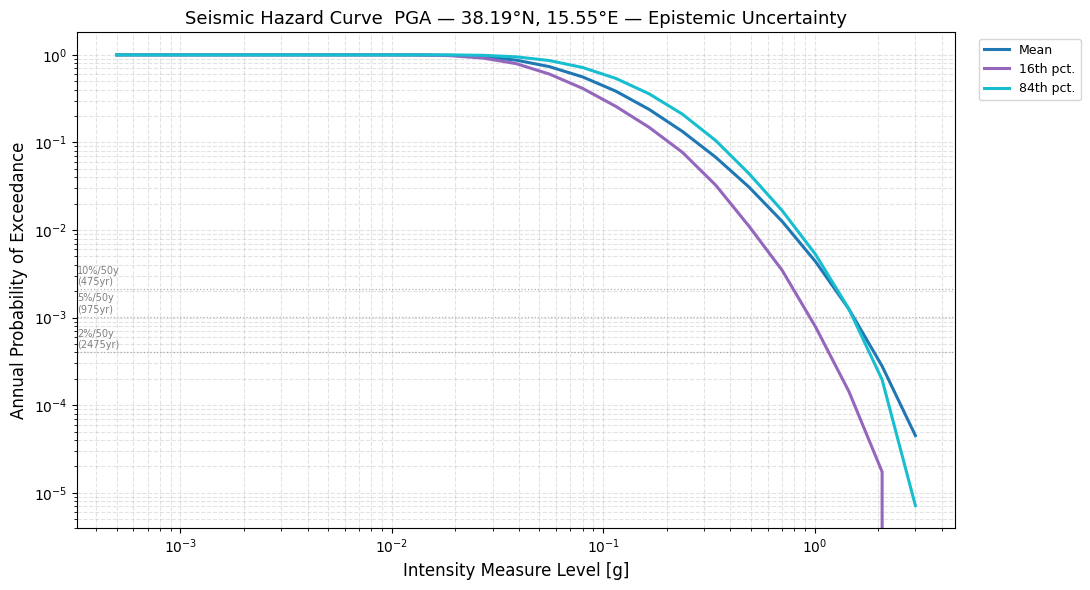

In [7]:
# ============================================================
#  EXERCISE B — uncertainty bands
# ============================================================
MODEL_NAME = 'European Seismic hazard Model 2020 (ESHM20)'   # edit if needed
IMT        = 'PGA'                   # edit if needed
SOIL       = 'rock_vs30_800ms-1'     # edit if needed

AGGREGATIONS = [
    ('arithmetic', '0.5',  'Mean'),
    ('ordinal',    '0.16', '16th pct.'),
    ('ordinal',    '0.84', '84th pct.'),
]

# --- Do not edit below this line ---
model = next((m for m in MODELS if m['name'] == MODEL_NAME), None)
if model is None:
    print(f"Model not found. Options: {[m['name'] for m in MODELS]}")
else:
    scenarios = []
    for agg_type, agg_level, agg_label in AGGREGATIONS:
        print(f'  Fetching {agg_label} ...')
        x, y = fetch_hazard_curve(LAT, LON, model['id'], IMT, SOIL, agg_type, agg_level)
        if x and y:
            scenarios.append({'label': agg_label, 'x': x, 'y': y})
    plot_scenarios(scenarios, 'curve',
                   title_suffix=f'{IMT} — {LAT}°N, {LON}°E — Epistemic Uncertainty')

## 8. Exercise C: Model comparison (ESHM13 vs. ESHM20)

**Task:** Compare the mean PGA hazard curve from ESHM13 (2013) and ESHM20 (2020).

**Learning goal:** ESHM20 incorporated updated source models, new ground-motion models (GMMs), and revised logic trees. Does the newer model predict higher or lower hazard at your site? Can you explain why?

  Fetching European Seismic Hazard Model ...
  Fetching European Seismic hazard Model ...


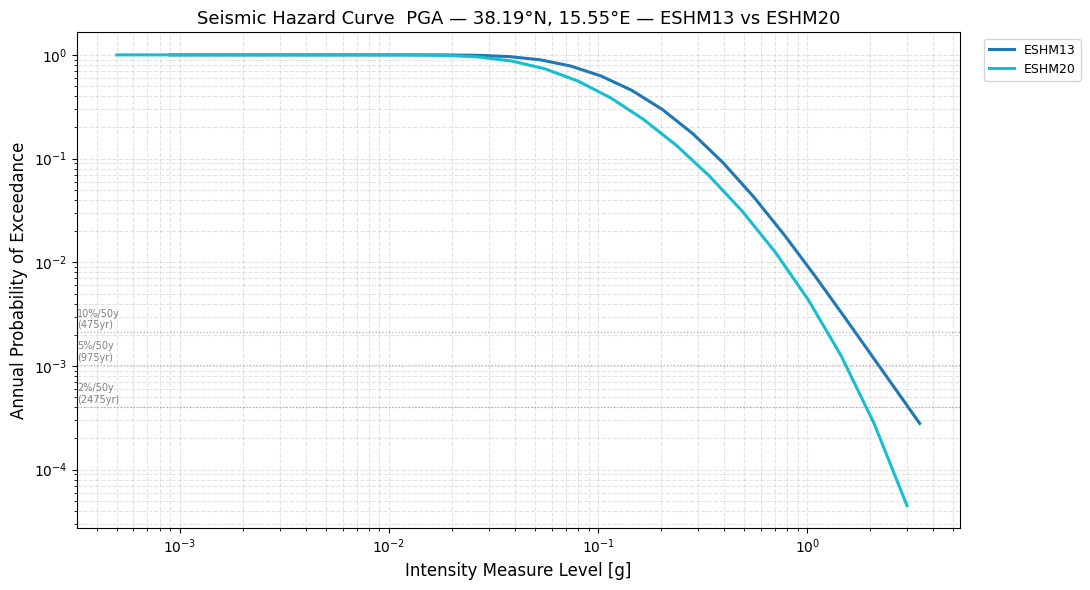

In [8]:
# ============================================================
#  EXERCISE C — model comparison ESHM13 vs. ESHM20
# ============================================================
IMT  = 'PGA'
SOIL = 'rock_vs30_800ms-1'

COMPARE_MODELS = [
    'European Seismic Hazard Model 2013 (ESHM13)',
    'European Seismic hazard Model 2020 (ESHM20)',
]

# --- Do not edit below this line ---
scenarios = []
for mname in COMPARE_MODELS:
    model = next((m for m in MODELS if m['name'] == mname), None)
    if model is None:
        print(f'  ⚠ Model not found: {mname}')
        continue
    print(f'  Fetching {mname[:30]}...')
    x, y = fetch_hazard_curve(LAT, LON, model['id'], IMT, SOIL, 'arithmetic', '0.5')
    if x and y:
        scenarios.append({'label': mname.split('(')[-1].rstrip(')'), 'x': x, 'y': y})

plot_scenarios(scenarios, 'curve',
               title_suffix=f'{IMT} — {LAT}°N, {LON}°E — ESHM13 vs ESHM20')

## 9. Exercise D: Uniform Hazard Spectrum (UHS)

**Task:** Plot the UHS for your site at the 475-year return period (Eurocode design level).

**Learning goal:** The UHS shows how spectral acceleration varies with structural period. Short-period structures (stiff buildings, T < 0.2 s) experience higher accelerations; long-period structures (flexible/tall, T > 1 s) experience lower accelerations — but the relationship depends on the source-to-site distance and the rupture characteristics.

**Note on PoE format:** ESHM20 stores PoEs as annual rates. The 475-year RP corresponds to an annual rate of ~0.002103 (= 1/475). Use the labels from Notebook 1 to identify the correct value.

In [9]:
# ============================================================
#  EXERCISE D — Uniform Hazard Spectrum
# ============================================================
UHS_SETTINGS = {
    'model_name' : 'European Seismic hazard Model 2020 (ESHM20)',
    'soil_type'  : 'rock_vs30_800ms-1',
    'agg_type'   : 'arithmetic',
    'agg_level'  : '0.5',
    # --- PoE: choose from Notebook 1 output ---
    # ESHM20 uses annual rates. Common values:
    #   ~475-yr RP  (10%/50y) → prob='0.002103', years='1'
    #   ~975-yr RP  ( 5%/50y) → prob='0.0010249', years='1'
    #   ~2475-yr RP ( 2%/50y) → prob='3.99999E-4', years='1'
    'poe_prob'   : '0.002103',   # annual exceedance probability
    'poe_years'  : '1',          # timespan (1 = annual rate for ESHM20)
    'debug'      : False,
}

# --- Do not edit below this line ---
model = next((m for m in MODELS if m['name'] == UHS_SETTINGS['model_name']), None)
if model is None:
    print(f"Model not found. Options: {[m['name'] for m in MODELS]}")
else:
    print(f"Fetching UHS for {LAT}°N, {LON}°E ...")
    periods, sa_vals = fetch_uhs(
        LAT, LON, model['id'],
        UHS_SETTINGS['soil_type'],
        UHS_SETTINGS['agg_type'], UHS_SETTINGS['agg_level'],
        UHS_SETTINGS['poe_prob'], UHS_SETTINGS['poe_years'],
        debug=UHS_SETTINGS['debug']
    )
    label = (f"{UHS_SETTINGS['model_name'][:20]}… | "
             f"PoE {UHS_SETTINGS['poe_prob']} in {UHS_SETTINGS['poe_years']}yr | "
             f"{UHS_SETTINGS['agg_type']} {UHS_SETTINGS['agg_level']}")
    plot_scenarios(
        [{'label': label, 'x': periods, 'y': sa_vals}],
        plot_type='uhs',
        title_suffix=f'— {LAT}°N, {LON}°E  (475-yr RP)'
    )

Fetching UHS for 38.19°N, 15.55°E ...

⚠ No data to plot. Possible reasons:
  • The model does not cover this location
  • The PoE / soil type combination is not available
  • Network error — try re-running with debug=True in the fetch calls


## 10. Exercise E: Location comparison

**Task:** Compare hazard curves for multiple Italian cities on the same plot.

**Learning goal:** Hazard varies dramatically across Italy. Messina is among the highest-hazard cities in Europe. Compare it to lower-hazard northern Italian cities and discuss the reasons in terms of tectonic setting.

  Fetching Messina (38.19°N, 15.55°E) ...
  Fetching L'Aquila (42.35°N, 13.4°E) ...
  Fetching Naples (40.85°N, 14.27°E) ...
  Fetching Rome (41.9°N, 12.5°E) ...
  Fetching Milan (45.46°N, 9.19°E) ...


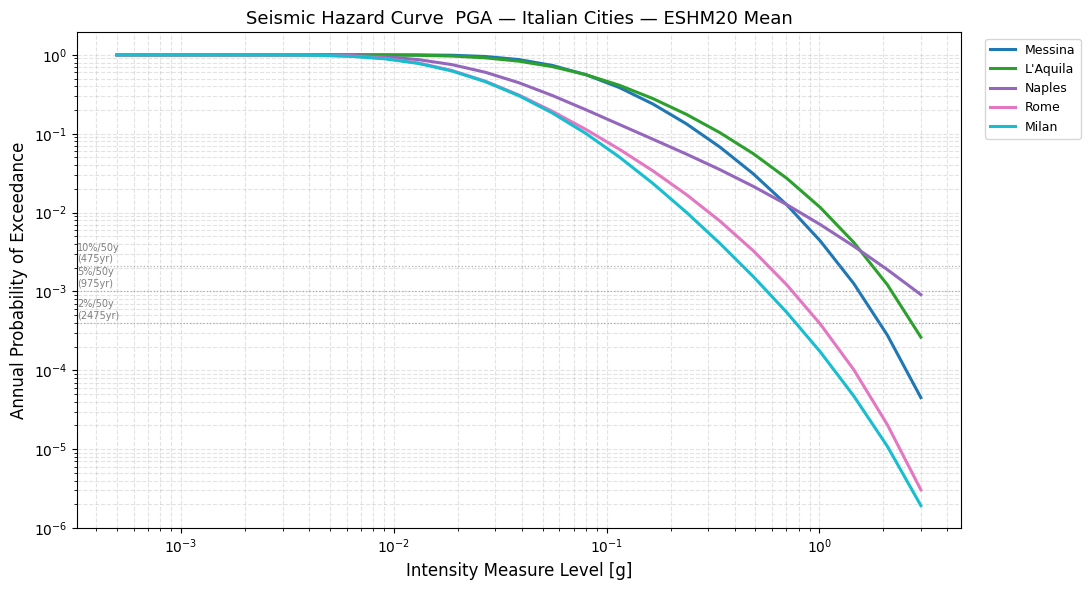

In [10]:
# ============================================================
#  EXERCISE E — compare hazard across locations
# ============================================================
LOCATIONS = [
    {'label': 'Messina',   'lat': 38.19, 'lon': 15.55},
    {'label': "L'Aquila",  'lat': 42.35, 'lon': 13.40},
    {'label': 'Naples',    'lat': 40.85, 'lon': 14.27},
    {'label': 'Rome',      'lat': 41.90, 'lon': 12.50},
    {'label': 'Milan',     'lat': 45.46, 'lon':  9.19},
]

LOC_MODEL_NAME = 'European Seismic hazard Model 2020 (ESHM20)'
LOC_IMT        = 'PGA'
LOC_SOIL       = 'rock_vs30_800ms-1'

# --- Do not edit below this line ---
model = next((m for m in MODELS if m['name'] == LOC_MODEL_NAME), None)
if model is None:
    print(f"Model not found. Options: {[m['name'] for m in MODELS]}")
else:
    scenarios = []
    for loc in LOCATIONS:
        print(f"  Fetching {loc['label']} ({loc['lat']}°N, {loc['lon']}°E) ...")
        x, y = fetch_hazard_curve(
            loc['lat'], loc['lon'], model['id'],
            LOC_IMT, LOC_SOIL, 'arithmetic', '0.5'
        )
        if x and y:
            scenarios.append({'label': loc['label'], 'x': x, 'y': y})
        else:
            print(f"    ⚠ No data for {loc['label']}")

    plot_scenarios(scenarios, 'curve',
                   title_suffix=f'{LOC_IMT} — Italian Cities — ESHM20 Mean')

## 11. Debug utility

If a fetch returns no data, run this cell with the parameters that failed. It will print the raw API URL and the first 800 characters of the server response so you can inspect the XML structure.

In [11]:
# ============================================================
#  DEBUG — inspect raw API response
# ============================================================
DEBUG_QUERY = {
    'endpoint': 'spectra',           # 'curve' or 'spectra'
    'model_id': '81',                # from config
    'lat': LAT,
    'lon': LON,
    'imt': 'SA',
    'soil': 'rock_vs30_800ms-1',
    'agg_type': 'arithmetic',
    'agg_level': '0.5',
    'poe': '0.002103',               # for spectra endpoint
    'timespan': '1',
}

if DEBUG_QUERY['endpoint'] == 'curve':
    url = (f"{BASE_URL}/curve?id={DEBUG_QUERY['model_id']}"
           f"&lat={DEBUG_QUERY['lat']}&lon={DEBUG_QUERY['lon']}"
           f"&imt={DEBUG_QUERY['imt']}&soiltype={DEBUG_QUERY['soil']}"
           f"&aggregationtype={DEBUG_QUERY['agg_type']}"
           f"&aggregationlevel={DEBUG_QUERY['agg_level']}")
else:
    url = (f"{BASE_URL}/spectra?id={DEBUG_QUERY['model_id']}"
           f"&lat={DEBUG_QUERY['lat']}&lon={DEBUG_QUERY['lon']}"
           f"&imt={DEBUG_QUERY['imt']}&soiltype={DEBUG_QUERY['soil']}"
           f"&aggregationtype={DEBUG_QUERY['agg_type']}"
           f"&aggregationlevel={DEBUG_QUERY['agg_level']}"
           f"&poe={DEBUG_QUERY['poe']}&timespanpoe={DEBUG_QUERY['timespan']}")

print(f'URL: {url}\n')
try:
    r = requests.get(url, timeout=30)
    print(f'HTTP status: {r.status_code}')
    print(f'Response snippet:\n{r.text[:800]}')
except Exception as e:
    print(f'Error: {e}')

URL: http://appsrvr.share-eu.org:8080/share/spectra?id=81&lat=38.19&lon=15.55&imt=SA&soiltype=rock_vs30_800ms-1&aggregationtype=arithmetic&aggregationlevel=0.5&poe=0.002103&timespanpoe=1

HTTP status: 200
Response snippet:
<?xml version="1.0" encoding="UTF-8" standalone="yes"?>
<ns2:nrml xmlns:ns2="http://openquake.org/xmlns/nrml/0.3" xmlns:ns1="http://www.opengis.net/gml" xmlns:ns4="http://www.w3.org/1999/xlink" xmlns:ns3="http://quakeml.org/xmlns/quakeml/1.1">
    <ns2:hazardResult ns1:id="gml_id_25029">
        <ns2:config>
            <ns2:hazardProcessing saDamping="0.05" IDmodel="" investigationTimeSpan="1.0"/>
        </ns2:config>
        <ns2:hazardSpectraField quantileValue="0.5" statistics="mean" PoE="0.002103" ns1:id="gml_id_25030">
            <ns2:spectraPeriodList>0.0 0.05 0.1 0.15 0.2 0.25 0.3 0.35 0.4 0.5 0.6 0.75 1.0 2.0 3.0 4.0 5.0</ns2:spectraPeriodList>
            <ns2:HSNode ns1:id="gml_id_25031">
                <ns2:site>
                    <ns1:Point srsName=

## Summary of exercises

| Exercise | What you plotted | Key question |
|----------|-----------------|-------------|
| A | Single hazard curve | What is the 475-yr PGA at your site? |
| B | Mean ± epistemic uncertainty | How wide is the uncertainty band? |
| C | ESHM13 vs. ESHM20 | Did hazard increase or decrease? |
| D | Uniform Hazard Spectrum | Which structural period is most critical? |
| E | Italian cities comparison | Which city has highest hazard, and why? |

### Further exploration

- **SA at different periods:** In Exercise A, change `imt` to `'SA[0.20s]'` or `'SA[1.00s]'` and compare with PGA. How does the shape of the hazard curve change with period?
- **Compare UHS at different return periods:** In Exercise D, switch between the 475-yr, 975-yr, and 2475-yr PoE values. What happens to the spectral shape?
- **Non-rock sites:** The API only provides rock-reference hazard. To estimate hazard on softer soil, multiply SA values by the Eurocode 8 soil amplification factor S for your Vs30.

*EFEHR/SHARE API — http://appsrvr.share-eu.org:8080/share*  
*GeoINquire project — Messina Workshop, April 2026*